# **Deep Learning Assigment - 4**
## Name: Anumalasetty Sohan Kumar
## Roll No.: CS23B1004

## Name: Shishir Kumar Reddy Ambala
## Roll No.: CS23B2043
---

# Deepfake Detection using ResNet-34 and ResNet-152

## 1. Objective

The objective of this assignment is to develop a deep learning model capable of detecting deepfake images using convolutional neural networks. The study focuses on implementing and evaluating two architectures: a manually implemented ResNet-34 model and a pretrained ResNet-152 model. The goal is to understand the effectiveness of deep residual networks in identifying manipulated media.

---

## 2. Problem Statement

Deepfakes are synthetic media generated using deep learning techniques that manipulate facial expressions and identities in images or videos. These manipulated contents pose significant risks in areas such as misinformation, identity theft, and digital security. Therefore, robust deepfake detection systems are required to distinguish between real and fake media.

This assignment aims to classify images into two categories:
- **Real**
- **Fake (Deepfake)**

---

## 3. Dataset Description

The dataset used in this assignment consists of images labeled as real or fake along with metadata that contains information about the image files. The dataset is provided through Google Drive links and contains images extracted from deepfake datasets.

## 4. Dataset Components

- Image files used for training and testing
- Metadata file containing labels and image information

## 6 Mount Google Drive & Extract Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Paths to files on Google Drive
BASE_PATH = "/content/drive/MyDrive"
TAR_PATH = os.path.join(BASE_PATH, "deepfake_dataset.tar.gz")
CELEB_CSV_PATH = os.path.join(BASE_PATH, "celebdf.csv")
FFPP_CSV_PATH = os.path.join(BASE_PATH, "ffpp.csv")

# Extract dataset to local runtime for speed
EXTRACT_DIR = "/content"
if not os.path.exists(os.path.join(EXTRACT_DIR, "CelebDF")):
    print("Extracting dataset to local runtime...")
    !tar -xzf "$TAR_PATH" -C /content/
    print("Extraction complete!")
else:
    print("Dataset already extracted.")

# Verify extraction
print("\nExtracted directories:")
!ls -la /content/CelebDF/ | head -5
!ls -la /content/FFPP/ | head -5

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already extracted.

Extracted directories:
total 48
drwxr-xr-x 5  501 staff  4096 Mar  2 05:43 .
drwxr-xr-x 1 root root   4096 Mar  7 12:42 ..
-rw-r--r-- 1  501 staff   120 Mar  2 05:33 ._.DS_Store
-rw-r--r-- 1  501 staff 10244 Mar  2 05:33 .DS_Store
total 32
drwxr-xr-x 5  501 staff 4096 Mar  2 06:29 .
drwxr-xr-x 1 root root  4096 Mar  7 12:42 ..
-rwxr-xr-x 1  501 staff  170 Mar  2 06:28 ._test
drwxr-xr-x 4  501 staff 4096 Mar  7 12:42 test


## 1. Install Dependencies & Import Libraries

In [2]:
!pip install -q tqdm scikit-learn matplotlib seaborn

import os, copy, time, warnings
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Configuration

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cpu


## 3. Load and Combine Metadata CSVs

In [ ]:
# Load CSV files from Google Drive
df_celebdf = pd.read_csv(CELEB_CSV_PATH)
df_ffpp    = pd.read_csv(FFPP_CSV_PATH)

# Keep only required columns
df_celebdf = df_celebdf[["image_path", "label"]]
df_ffpp    = df_ffpp[["image_path", "label"]]

# Combine both datasets
df_all = pd.concat(
    [df_celebdf, df_ffpp],
    ignore_index=True
)

print(f"CelebDF samples: {len(df_celebdf)}")
print(f"FFPP samples:    {len(df_ffpp)}")
print(f"Total combined:  {len(df_all)}")

print(f"\nLabel distribution:\n{df_all['label'].value_counts()}")

print("\nSample rows:")
df_all.head()

CelebDF samples: 52217
FFPP samples:    47981
Total combined:  100198

Label distribution:
label
1    85093
0    15105
Name: count, dtype: int64

Sample rows:


,image_path,label
0,CelebDF/train/fake/id17_id26_0005_0.jpg,1
1,CelebDF/train/fake/id17_id26_0005_1.jpg,1
2,CelebDF/train/fake/id17_id26_0005_2.jpg,1
3,CelebDF/train/fake/id17_id26_0005_3.jpg,1
4,CelebDF/train/fake/id17_id26_0005_4.jpg,1


## 4. Split Data

In [ ]:
# Split data using folder names in image_path
train_df = df_all[df_all["image_path"].str.contains("/train/")].reset_index(drop=True)
val_df   = df_all[df_all["image_path"].str.contains("/val/")].reset_index(drop=True)
test_df  = df_all[df_all["image_path"].str.contains("/test/")].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

print(f"\nTrain label dist: {dict(train_df['label'].value_counts())}")
print(f"Val   label dist: {dict(val_df['label'].value_counts())}")
print(f"Test  label dist: {dict(test_df['label'].value_counts())}")

Train: 74444 | Val: 14413 | Test: 11341

Train label dist: {1: np.int64(63952), 0: np.int64(10492)}
Val   label dist: {1: np.int64(12421), 0: np.int64(1992)}
Test  label dist: {1: np.int64(8720), 0: np.int64(2621)}


## 5. Dataset Class

Reads image paths from the CSV DataFrame, loads images using PIL, and applies transforms.

In [ ]:
class DeepfakeDataset(Dataset):
    """
    Custom dataset for deepfake detection from CSV metadata.
    """

    def __init__(self, dataframe, base_dir="/content", transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_relative_path = row["image_path"]
        img_path = os.path.join(self.base_dir, img_relative_path)

        label = int(row["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

DeepfakeDataset class defined.


## 6. Data Transforms

In [ ]:
IMG_SIZE = 224

# ImageNet statistics for normalization
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2
        ),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]
)

val_test_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]
)

Transforms defined.


## 7. Create Datasets and DataLoaders

In [ ]:
BATCH_SIZE   = 32
IMG_BASE_DIR = "/content"

train_dataset = DeepfakeDataset(
    train_df,
    IMG_BASE_DIR,
    transform=train_transform
)

val_dataset = DeepfakeDataset(
    val_df,
    IMG_BASE_DIR,
    transform=val_test_transform
)

test_dataset = DeepfakeDataset(
    test_df,
    IMG_BASE_DIR,
    transform=val_test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Verify a batch
imgs, labels = next(iter(train_loader))

print(f"\nBatch shape: {imgs.shape}, Labels: {labels[:8]}")

Train batches: 2327
Val batches:   451
Test batches:  355

Batch shape: torch.Size([32, 3, 224, 224]), Labels: tensor([1, 1, 1, 1, 1, 1, 0, 1])


## 8. Training Images

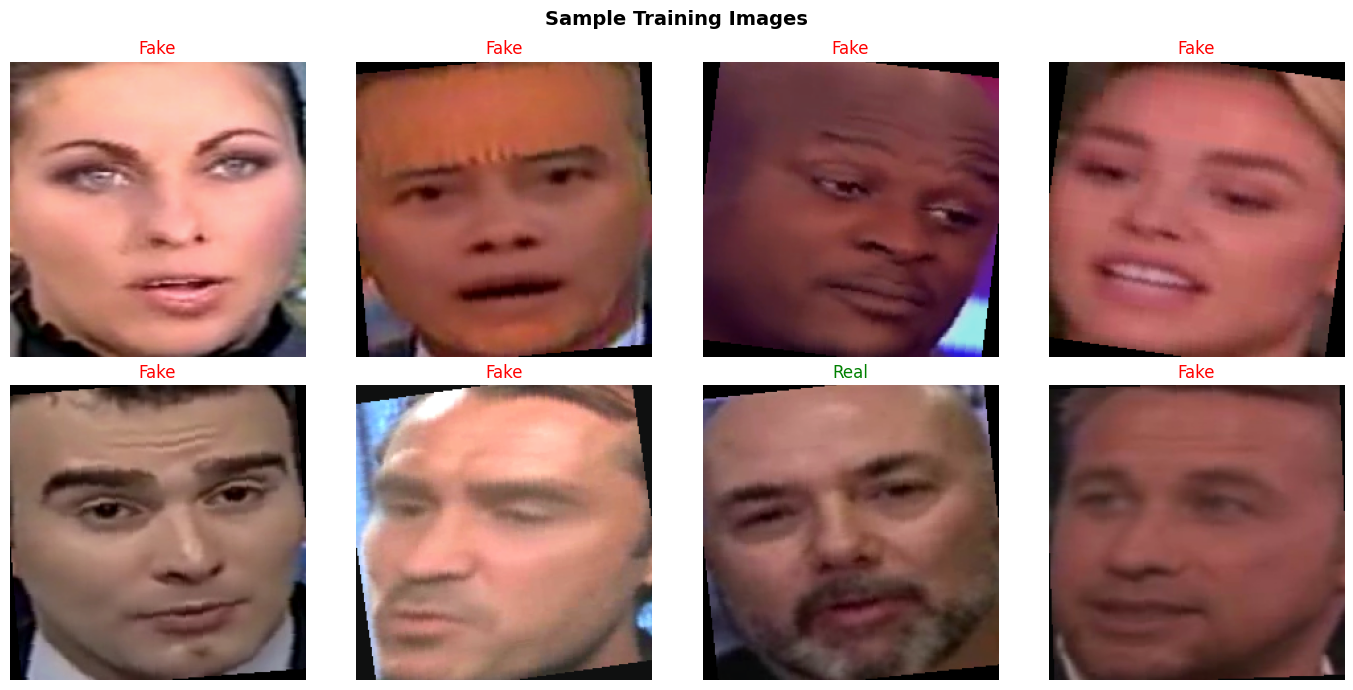

In [ ]:
def imshow(img, title=""):
    """Unnormalize and display image."""
    img = img.cpu().numpy().transpose((1, 2, 0))
    img = np.array(STD) * img + np.array(MEAN)
    img = np.clip(img, 0, 1)
    return img


fig, axes = plt.subplots(2, 4, figsize=(14, 7))

label_map = {
    0: "Real",
    1: "Fake"
}

for i, ax in enumerate(axes.flat):
    ax.imshow(imshow(imgs[i]))

    ax.set_title(
        f"{label_map[labels[i].item()]}",
        fontsize=12,
        color="green" if labels[i].item() == 0 else "red"
    )

    ax.axis("off")

plt.suptitle(
    "Training Images",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 9. ResNet-34

In [ ]:
class BasicBlock(nn.Module):
    """Basic residual block for ResNet-18/34."""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity  # Skip connection
        out = self.relu(out)

        return out


class ResNet34Manual(nn.Module):
    """ResNet-34 built manually from basic layers."""

    def __init__(self, num_classes=2):
        super(ResNet34Manual, self).__init__()

        self.in_channels = 64

        # Initial convolution layer
        self.conv1 = nn.Conv2d(
            3, 64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        # Residual layers: [3, 4, 6, 3]
        self.layer1 = self._make_layer(64, 3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

        layers = [
            BasicBlock(
                self.in_channels,
                out_channels,
                stride,
                downsample
            )
        ]

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                BasicBlock(out_channels, out_channels)
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


# Instantiate and display
resnet34_manual = ResNet34Manual(num_classes=2).to(device)

total_params_34 = sum(p.numel() for p in resnet34_manual.parameters())
trainable_34 = sum(p.numel() for p in resnet34_manual.parameters() if p.requires_grad)

print("ResNet-34 (Manual) Architecture:")
print(resnet34_manual)

print(f"\nTotal parameters:     {total_params_34:,}")
print(f"Trainable parameters: {trainable_34:,}")

ResNet-34 (Manual) Architecture:
ResNet34Manual(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

## 11. Training & Validation Functions

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, model_name="model"):
    """Train model and return history."""

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):

        # --- Training phase ---
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{num_epochs} [Train]",
            leave=False
        )

        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                acc=f"{correct/total:.4f}"
            )

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total

        # --- Validation phase ---
        model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            pbar = tqdm(
                val_loader,
                desc=f"Epoch {epoch+1}/{num_epochs} [Val]",
                leave=False
            )

            for images, labels in pbar:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        epoch_val_loss = running_loss / total
        epoch_val_acc = correct / total

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}"
        )

        # Save best model to Google Drive
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

            save_path = os.path.join(BASE_PATH, f"best_{model_name}.pth")
            torch.save(model.state_dict(), save_path)

            print(f"  -> Best model saved to Drive! Val Acc: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)

    print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")

    return model, history

Training function defined.


## 12. Plotting Utility (Loss & Accuracy Curves)

In [ ]:
def plot_history(history, title=""):
    """Plot training and validation loss/accuracy curves."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    ax1.plot(history["train_loss"], "b-o", label="Train Loss")
    ax1.plot(history["val_loss"], "r-o", label="Val Loss")

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} - Loss Curves")

    ax1.legend()
    ax1.grid(True)

    # Accuracy curves
    ax2.plot(history["train_acc"], "b-o", label="Train Acc")
    ax2.plot(history["val_acc"], "r-o", label="Val Acc")

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} - Accuracy Curves")

    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

Plotting function defined.


## 13. Experiment 1 — ResNet-34 | Adam | lr=1e-3 | Batch=32

**Hyperparameters:**
- Model: ResNet-34 (manual)
- Optimizer: Adam
- Learning Rate: 1e-3
- Batch Size: 32
- Epochs: 5

In [ ]:
import os

NUM_EPOCHS = 5

MODEL_PATH = "/content/drive/MyDrive/best_resnet34_exp1.pth"

# Reinitialize model
model_34_exp1 = ResNet34Manual(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_34_exp1 = optim.Adam(
    model_34_exp1.parameters(),
    lr=1e-3
)

if os.path.exists(MODEL_PATH):

    print("Model already exists in Drive. Skipping training...")

    model_34_exp1.load_state_dict(
        torch.load(MODEL_PATH, map_location=device)
    )

    print("Model loaded successfully.")

else:

    print("Model not found. Starting training...")

    model_34_exp1, history_34_exp1 = train_model(
        model_34_exp1,
        train_loader,
        val_loader,
        criterion,
        optimizer_34_exp1,
        num_epochs=NUM_EPOCHS,
        model_name="resnet34_exp1"
    )

    print("Training completed successfully.")

    plot_history(
        history_34_exp1,
        title="ResNet-34 (Scratch) | Adam | lr=1e-3"
    )

✅ Model already exists in Drive. Skipping training...
Model loaded successfully.


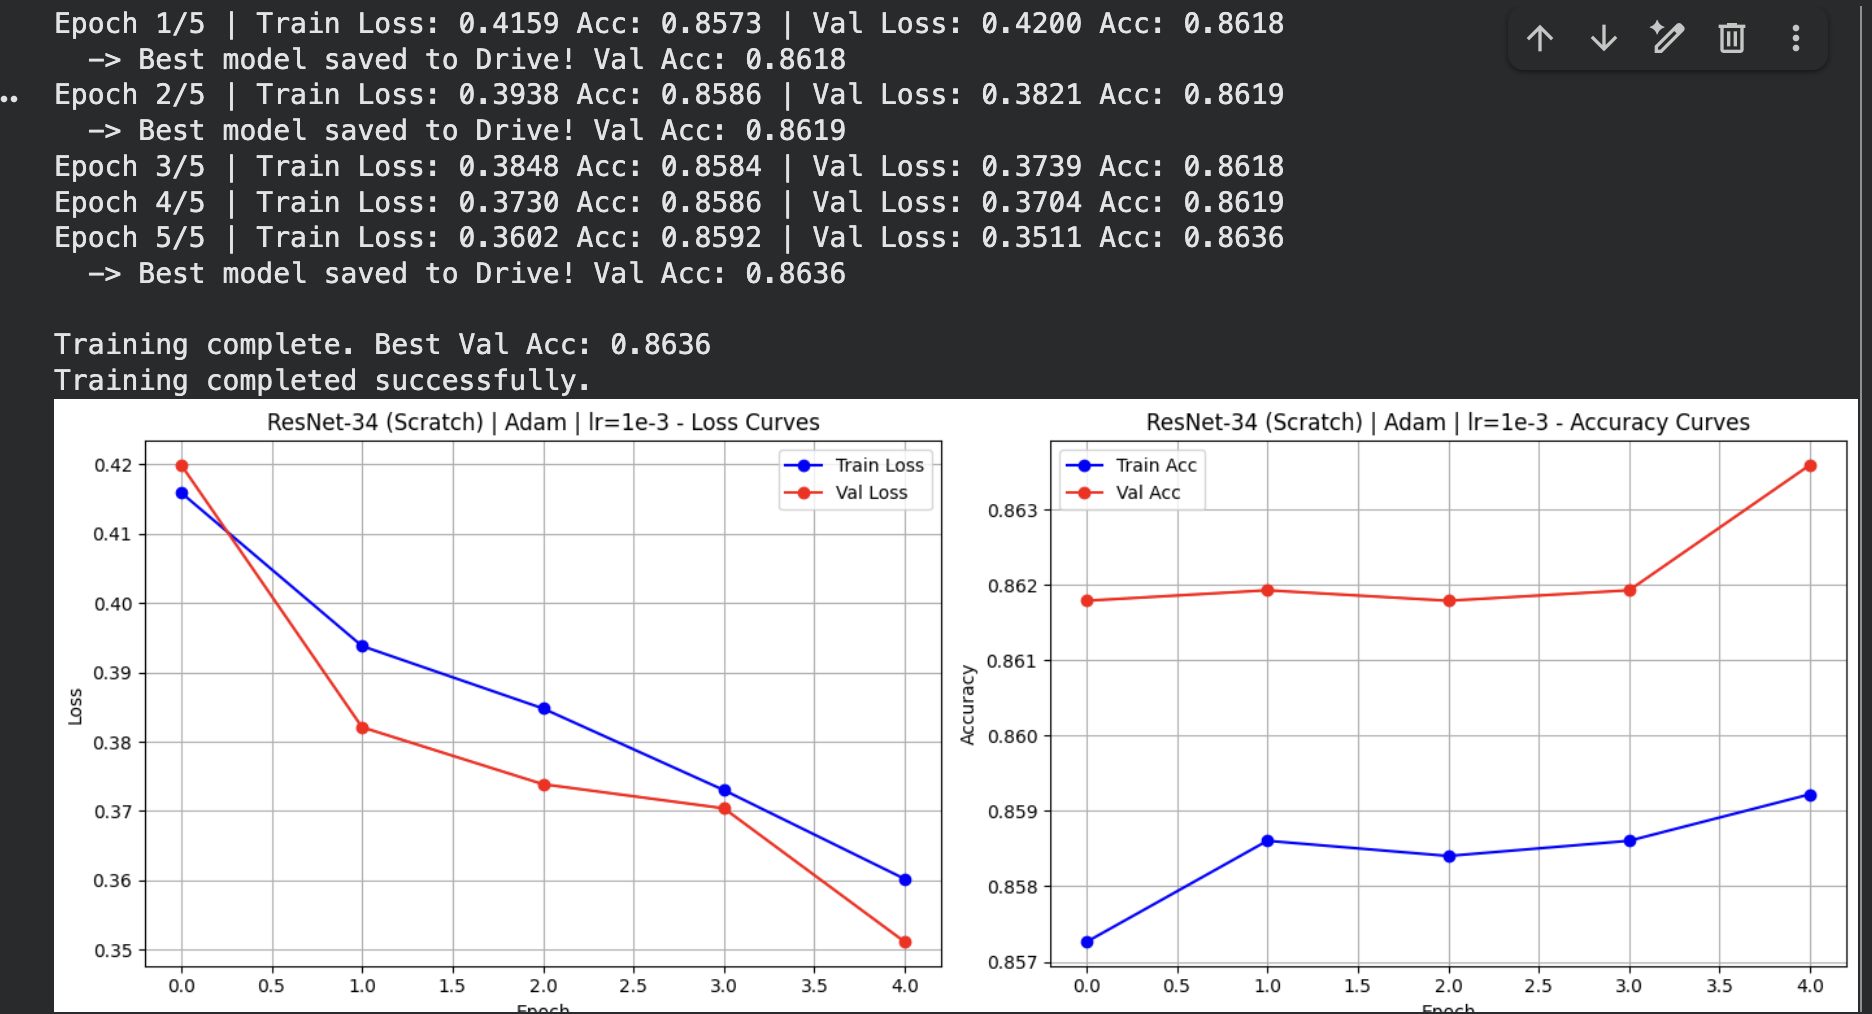

### Experiment 1 — Observations

**What was changed:** Baseline experiment with ResNet-34 trained from scratch using Adam optimizer at lr=1e-3.

**What happened:** The model starts learning from random weights. Training loss should decrease steadily. Validation accuracy may be moderate since the model is trained from scratch without pretrained features.

**Why:** Adam's adaptive learning rates help with initial convergence. lr=1e-3 is a standard starting point. However, training from scratch on a relatively small dataset may lead to slower convergence compared to a pretrained model.

## 14. Experiment 2 — ResNet-34 | SGD (momentum=0.9) | lr=1e-3 | Batch=32

In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/best_resnet34_exp2.pth"

model_34_exp2 = ResNet34Manual(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_34_exp2 = optim.SGD(
    model_34_exp2.parameters(),
    lr=1e-3,
    momentum=0.9,
    weight_decay=1e-4
)

if os.path.exists(MODEL_PATH):

    print("Model already exists in Drive. Skipping training...")

    model_34_exp2.load_state_dict(
        torch.load(MODEL_PATH, map_location=device)
    )

    print("Model loaded successfully.")

else:

    print("🚀 Model not found. Starting training...")

    model_34_exp2, history_34_exp2 = train_model(
        model_34_exp2,
        train_loader,
        val_loader,
        criterion,
        optimizer_34_exp2,
        num_epochs=NUM_EPOCHS,
        model_name="resnet34_exp2"
    )

    print("Training completed successfully.")

    plot_history(
        history_34_exp2,
        title="ResNet-34 (Scratch) | SGD (m=0.9) | lr=1e-3"
    )

✅ Model already exists in Drive. Skipping training...
Model loaded successfully.


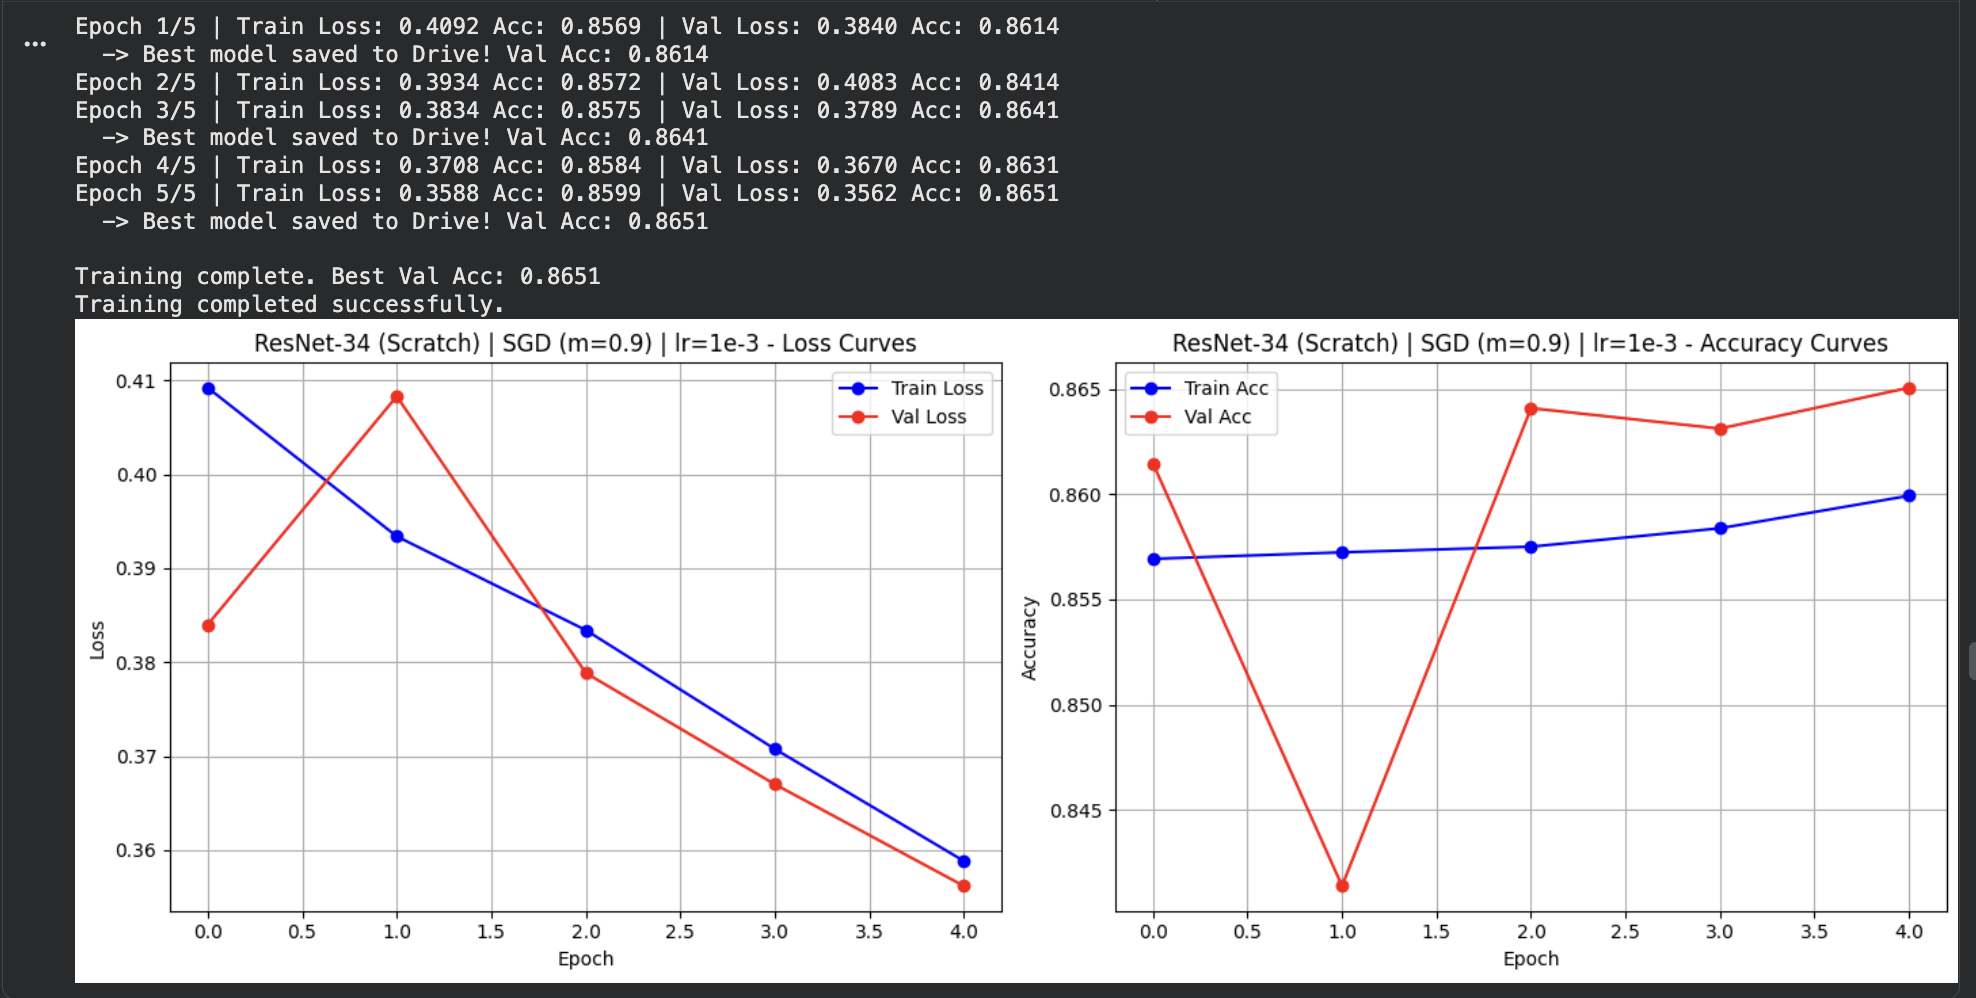

### Experiment 2 — Observations

**What was changed:** Switched from Adam to SGD with momentum=0.9 and weight decay=1e-4.

**What happened:** SGD with momentum typically converges more slowly initially than Adam but can generalize better. Weight decay acts as L2 regularization.

**Why:** SGD often finds flatter minima which can lead to better generalization. However, without a learning rate schedule, it may underperform Adam in limited epochs.

## 15. Experiment 3 — ResNet-34 | Adam | lr=1e-4 | Batch=64

In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/best_resnet34_exp3.pth"

# Rebuild loaders with batch_size = 64
train_loader_64 = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_64 = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

model_34_exp3 = ResNet34Manual(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_34_exp3 = optim.Adam(
    model_34_exp3.parameters(),
    lr=1e-4
)

if os.path.exists(MODEL_PATH):

    print("Model already exists in Drive. Skipping training...")

    model_34_exp3.load_state_dict(
        torch.load(MODEL_PATH, map_location=device)
    )

    print("Loaded best_resnet34_exp3.pth")

else:

    print("Model not found. Starting training...")

    model_34_exp3, history_34_exp3 = train_model(
        model_34_exp3,
        train_loader_64,
        val_loader_64,
        criterion,
        optimizer_34_exp3,
        num_epochs=NUM_EPOCHS,
        model_name="resnet34_exp3"
    )

    print("Training completed successfully.")

    plot_history(
        history_34_exp3,
        title="ResNet-34 (Scratch) | Adam | lr=1e-4 | Batch=64"
    )

✅ Model already exists in Drive. Skipping training...
✔ Loaded best_resnet34_exp3.pth


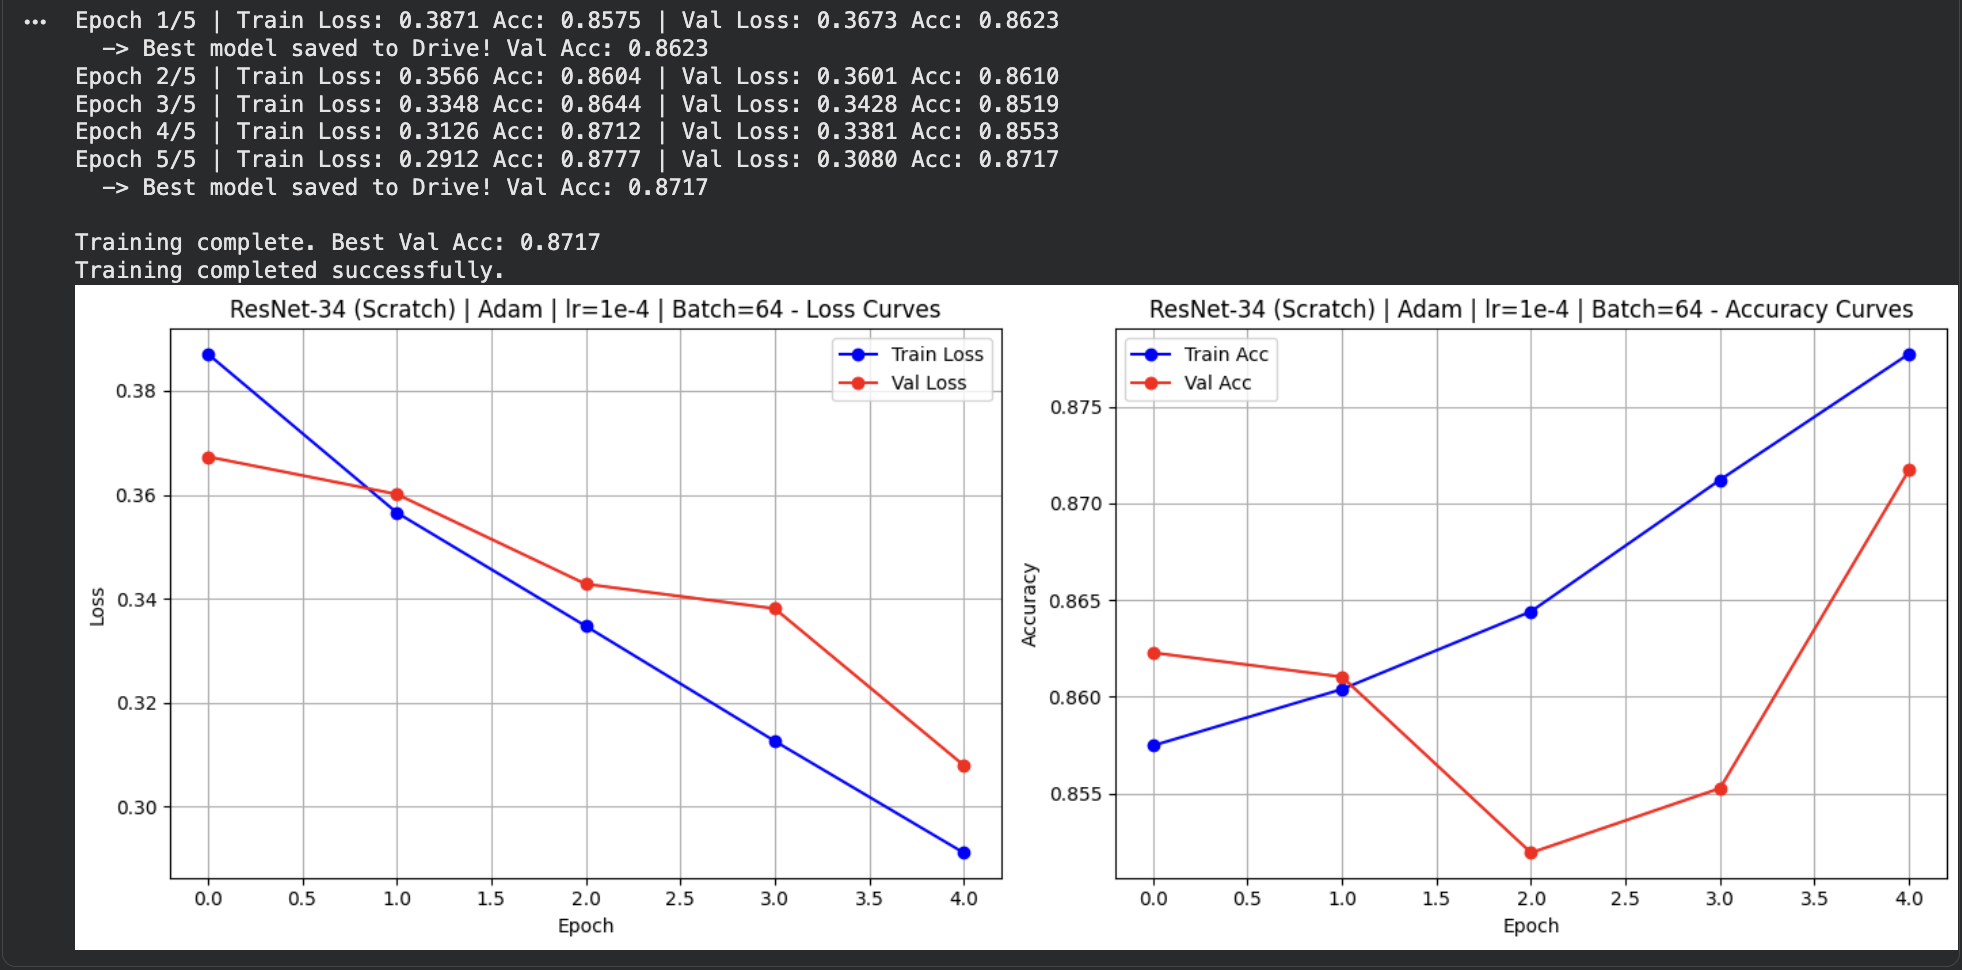

## 18. Evaluation Functions

In [ ]:
def evaluate_model(model, test_loader, model_name="Model"):
    """Full evaluation on test set with all metrics."""

    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}"):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)[:, 1]  # Prob of class 1 (fake)

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # --- Metrics ---
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_probs)

    # IoU and Dice for the positive class (fake = 1)
    tp = np.sum((all_preds == 1) & (all_labels == 1))
    fp = np.sum((all_preds == 1) & (all_labels == 0))
    fn = np.sum((all_preds == 0) & (all_labels == 1))

    iou = tp / (tp + fp + fn + 1e-8)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Set Results")
    print(f"{'='*50}")

    print(f"  Accuracy:   {acc:.4f}")
    print(f"  Precision:  {prec:.4f}")
    print(f"  Recall:     {rec:.4f}")
    print(f"  F1-Score:   {f1:.4f}")
    print(f"  IoU:        {iou:.4f}")
    print(f"  Dice Coeff: {dice:.4f}")
    print(f"  ROC-AUC:    {roc_auc:.4f}")

    print(f"{'='*50}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=["Real", "Fake"]))

    return all_labels, all_preds, all_probs, {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "iou": iou,
        "dice": dice,
        "roc_auc": roc_auc,
    }


def plot_confusion_matrix(labels, preds, model_name=""):
    """Plot confusion matrix."""

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"],
    )

    plt.title(f"Confusion Matrix — {model_name}")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()


def plot_roc_curve(labels, probs, model_name=""):
    """Plot ROC curve."""

    fpr, tpr, _ = roc_curve(labels, probs)
    auc_val = roc_auc_score(labels, probs)

    plt.figure(figsize=(7, 5))

    plt.plot(
        fpr,
        tpr,
        "b-",
        linewidth=2,
        label=f"{model_name} (AUC={auc_val:.4f})",
    )

    plt.plot(
        [0, 1],
        [0, 1],
        "r--",
        linewidth=1,
        label="Random",
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve — {model_name}")

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Evaluation functions defined.


## 19. Evaluate Best ResNet-34 on Test Set

Loaded best ResNet-34 from: /content/drive/MyDrive/best_resnet34_exp3.pth


Testing ResNet-34 (Manual):   0%|          | 0/355 [00:00<?, ?it/s]


  ResNet-34 (Manual) — Test Set Results
  Accuracy:   0.7962
  Precision:  0.8030
  Recall:     0.9739
  F1-Score:   0.8802
  IoU:        0.7861
  Dice Coeff: 0.8802
  ROC-AUC:    0.8040

Classification Report:
              precision    recall  f1-score   support

        Real       0.70      0.21      0.32      2621
        Fake       0.80      0.97      0.88      8720

    accuracy                           0.80     11341
   macro avg       0.75      0.59      0.60     11341
weighted avg       0.78      0.80      0.75     11341



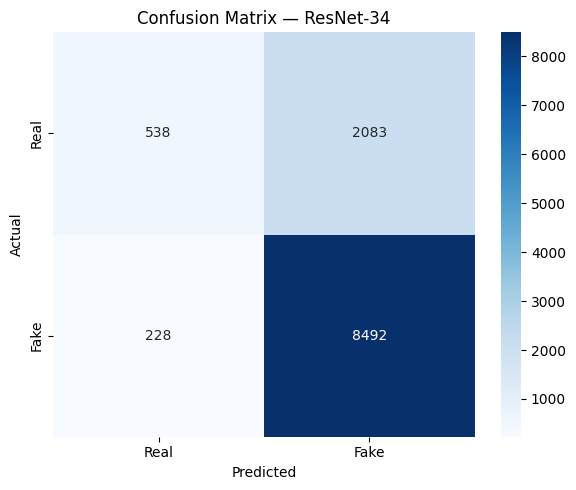

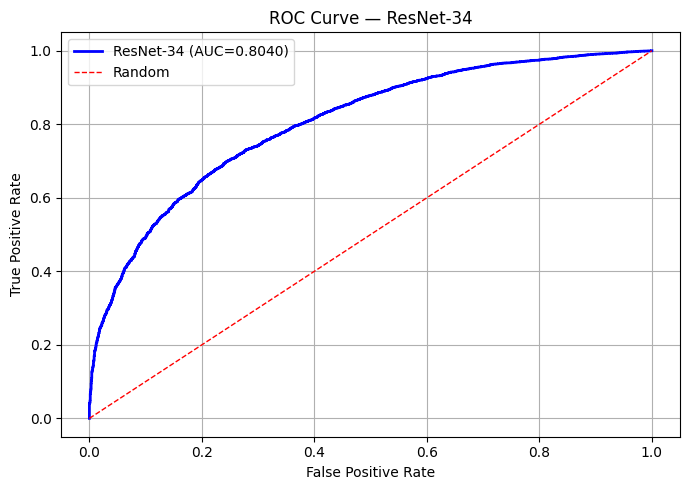

In [ ]:
# Load best ResNet-34 model from Google Drive
best_34 = ResNet34Manual(num_classes=2).to(device)

best_path_34 = os.path.join(BASE_PATH, "best_resnet34_exp1.pth")

for p in [
    "best_resnet34_exp1.pth",
    "best_resnet34_exp2.pth",
    "best_resnet34_exp3.pth",
]:
    full_p = os.path.join(BASE_PATH, p)

    if os.path.exists(full_p):
        best_path_34 = full_p

best_34.load_state_dict(
    torch.load(best_path_34, map_location=device)
)

print(f"Loaded best ResNet-34 from: {best_path_34}")

labels_34, preds_34, probs_34, metrics_34 = evaluate_model(
    best_34,
    test_loader,
    "ResNet-34 (Manual)"
)

plot_confusion_matrix(
    labels_34,
    preds_34,
    "ResNet-34"
)

plot_roc_curve(
    labels_34,
    probs_34,
    "ResNet-34"
)

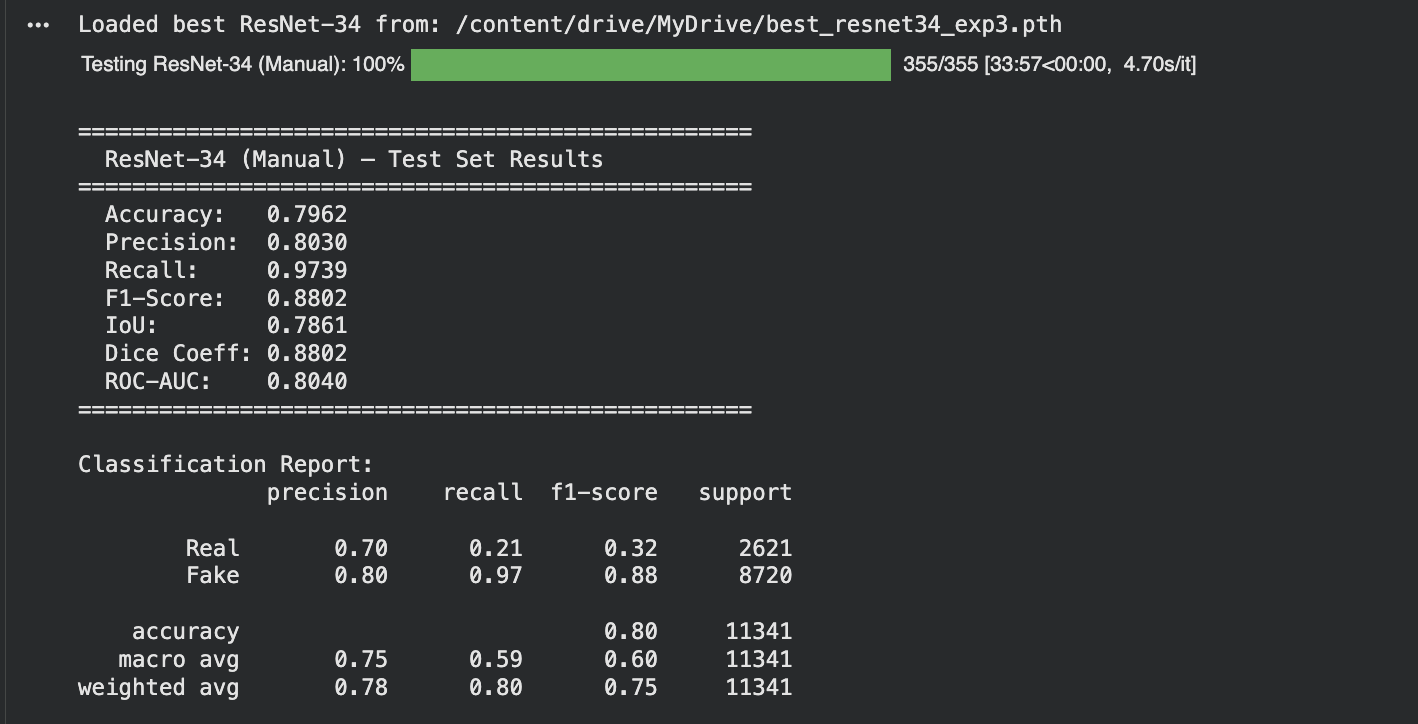
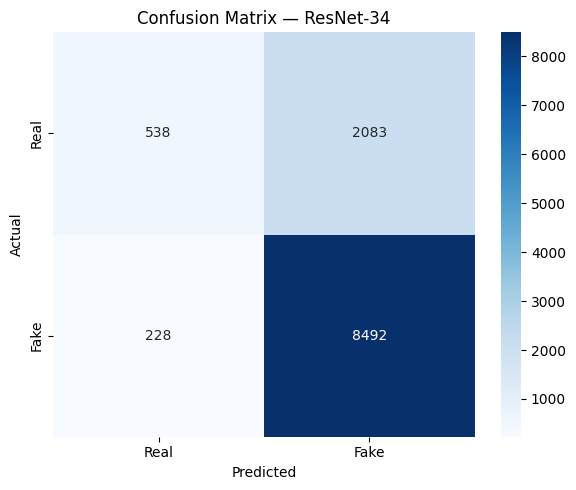
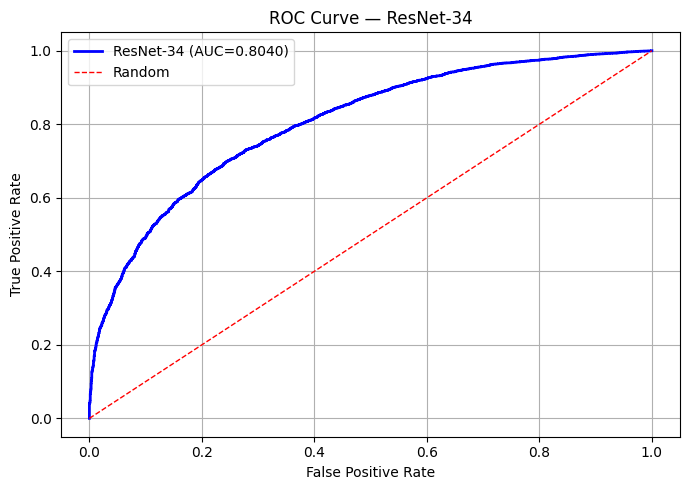